# Part A

## Generate Data and Least Squares Line

In [5]:
np.random.seed(0)

x = np.linspace(-5, 5, 50)
y = 2 * x**2 + 3 * x + np.random.randn(50) * 10

A = np.vstack([x, np.ones(len(x))]).T
m, c = np.linalg.lstsq(A, y, rcond=None)[0]

y_line = m * x + c

## Cubic Polynomial, MSE, and R-squared

In [10]:
degree = 3
coefficients = np.polyfit(x, y, degree)

print("Polynomial Coefficients:", coefficients)

polynomial = np.poly1d(coefficients)

y_poly = polynomial(x)

mse_line = np.mean((y - y_line)**2)
mse_poly = np.mean((y - y_poly)**2)

ss_res_line = np.sum((y - y_line)**2)
ss_res_poly = np.sum((y - y_poly)**2)

ss_tot = np.sum((y - np.mean(y))**2)

r2_line = 1 - ss_res_line/ss_tot
r2_poly = 1 - ss_res_poly/ss_tot


print("Least Squares Line")
print("Slope:", m)
print("Intercept:", c)
print("MSE:", mse_line)
print("R-squared:", r2_line)
print("Cubic Polynomial Fit")
print("MSE:", mse_poly)
print("R-squared:", r2_poly)

Polynomial Coefficients: [-0.06652428  2.09218103  2.62641665  0.60606342]
Least Squares Line
Slope: 1.5883775070098138
Intercept: 18.752531498641176
MSE: 372.0051625579934
R-squared: 0.05555558712253694
Cubic Polynomial Fit
MSE: 107.11173673839265
R-squared: 0.7280653832313249


## Determine Better Fit and Plot

Polynomial fit is the better fit


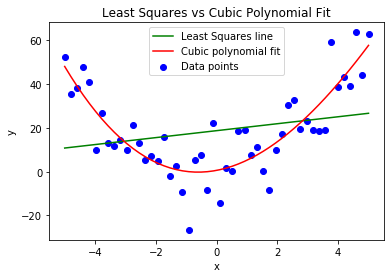

In [11]:
if mse_line < mse_poly:
    print("Least Squares is the better fit")
else:
    print("Polynomial fit is the better fit")


plt.scatter(x, y, color='blue', label='Data points')

plt.plot(x, y_line, color='green', label='Least Squares line')

plt.plot(x, y_poly, color='red', label='Cubic polynomial fit')

plt.title('Least Squares vs Cubic Polynomial Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.show()

# Part B

## Test Polynomial Degrees for Underfitting and Overfitting

Polynomial Degree: 1
MSE: 372.0051625579934
R-squared: 0.05555558712253694

Polynomial Degree: 2
MSE: 108.8859685268728
R-squared: 0.7235609745068399

Polynomial Degree: 3
MSE: 107.11173673839265
R-squared: 0.7280653832313249

Polynomial Degree: 4
MSE: 106.64598775650336
R-squared: 0.7292478238746859

Polynomial Degree: 5
MSE: 106.56131173306981
R-squared: 0.7294627988408573

Polynomial Degree: 6
MSE: 106.50809238892032
R-squared: 0.7295979117836278

Polynomial Degree: 7
MSE: 105.98312121449808
R-squared: 0.7309307053642209

Polynomial Degree: 8
MSE: 105.67991337764161
R-squared: 0.7317004875508192

Polynomial Degree: 9
MSE: 103.54514040275738
R-squared: 0.7371202360162101

Polynomial Degree: 10
MSE: 103.47182852225643
R-squared: 0.7373063597663768



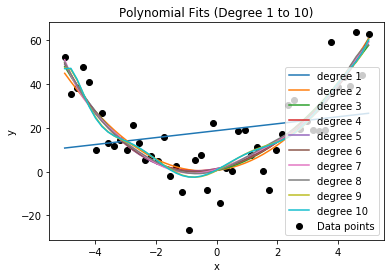

In [13]:
degrees = range(1, 11)

plt.scatter(x, y, color='black', label='Data points')

for degree in degrees:

    coefficients = np.polyfit(x, y, degree)
    polynomial = np.poly1d(coefficients)

    y_poly = polynomial(x)

    mse_poly = np.mean((y - y_poly)**2)

    ss_res = np.sum((y - y_poly)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2_poly = 1 - ss_res/ss_tot

    print("Polynomial Degree:", degree)
    print("MSE:", mse_poly)
    print("R-squared:", r2_poly)
    print()
    
    #plot

    plt.plot(x, y_poly, label=f'degree {degree}')

plt.title("Polynomial Fits (Degree 1 to 10)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

# Part C

## Vandermonde Matrix

Degree: 1
Coefficients: [18.7525315   1.58837751]
MSE: 372.0051625579934
R-squared: 0.05555558712253694

Degree: 2
Coefficients: [0.60606342 1.58837751 2.09218103]
MSE: 108.88596852687282
R-squared: 0.7235609745068399

Degree: 3
Coefficients: [ 0.60606342  2.62641665  2.09218103 -0.06652428]
MSE: 107.11173673839266
R-squared: 0.7280653832313249

Degree: 4
Coefficients: [ 1.37537166  2.62641665  1.79597142 -0.06652428  0.01329877]
MSE: 106.64598775650336
R-squared: 0.7292478238746859

Degree: 5
Coefficients: [ 1.37537166e+00  2.98283354e+00  1.79597142e+00 -1.30634817e-01
  1.32987706e-02  2.22280738e-03]
MSE: 106.56131173306983
R-squared: 0.7294627988408573

Degree: 6
Coefficients: [ 1.11433854e+00  2.98283354e+00  2.00766018e+00 -1.30634817e-01
 -1.12125372e-02  2.22280738e-03  6.93392045e-04]
MSE: 106.5080923889203
R-squared: 0.7295979117836278

Degree: 7
Coefficients: [ 1.11433854e+00  4.19720722e+00  2.00766018e+00 -5.53382317e-01
 -1.12125372e-02  3.81772193e-02  6.93392046e-04 -8

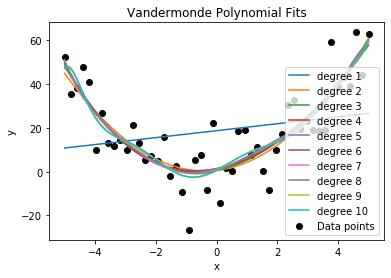

In [15]:
degrees = range(1, 11)

for degree in degrees:

    V = np.vander(x, N=degree+1, increasing=True)

    coefficients, _, _, _ = np.linalg.lstsq(V, y, rcond=None)

    y_pred = V @ coefficients

    mse = np.mean((y - y_pred)**2)

    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)

    r2 = 1 - ss_res/ss_tot

    print("Degree:", degree)
    print("Coefficients:", coefficients)
    print("MSE:", mse)
    print("R-squared:", r2)
    print()
    
#plot

plt.scatter(x, y, color='black', label='Data points')

x_smooth = np.linspace(np.min(x), np.max(x), 200)

for degree in degrees:

    V = np.vander(x, N=degree+1, increasing=True)
    coefficients, _, _, _ = np.linalg.lstsq(V, y, rcond=None)

    V_smooth = np.vander(x_smooth, N=degree+1, increasing=True)
    y_smooth = V_smooth @ coefficients

    plt.plot(x_smooth, y_smooth, label=f'degree {degree}')

plt.title("Vandermonde Polynomial Fits")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()